<a href="https://colab.research.google.com/github/jdcg5299/modelos-ai-portfolio/blob/main/Correa_Regresion_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

Cargando datos desde UCI Repository...

--- Resumen Estadístico ---
       X1 transaction date  X2 house age  \
count           414.000000    414.000000   
mean           2013.148971     17.712560   
std               0.281967     11.392485   
min            2012.667000      0.000000   
25%            2012.917000      9.025000   
50%            2013.167000     16.100000   
75%            2013.417000     28.150000   
max            2013.583000     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenience stores  X5 latitude  X6 longitude  \
count                   

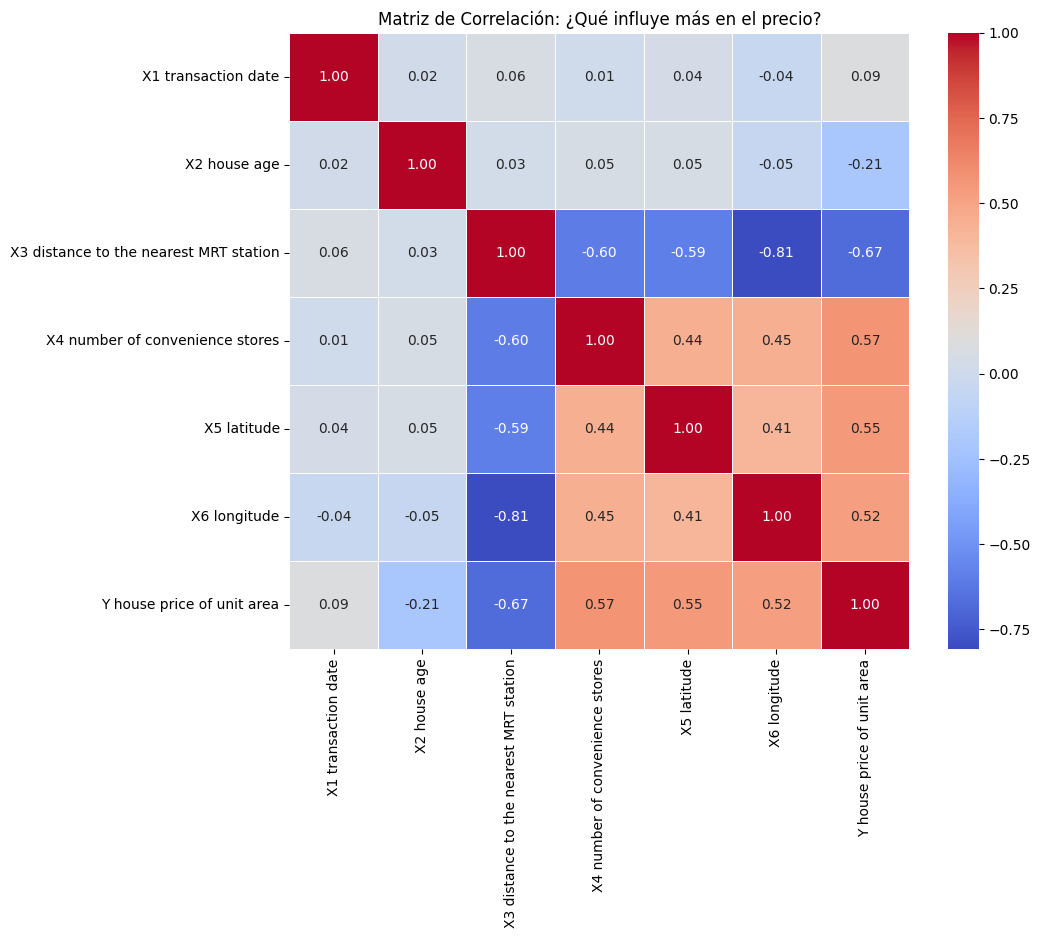

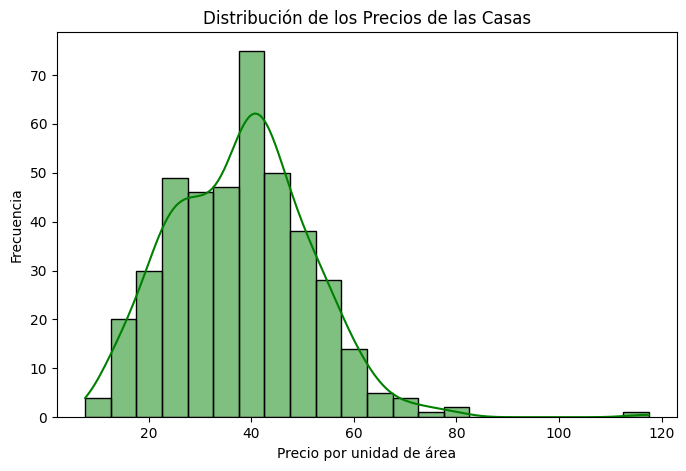

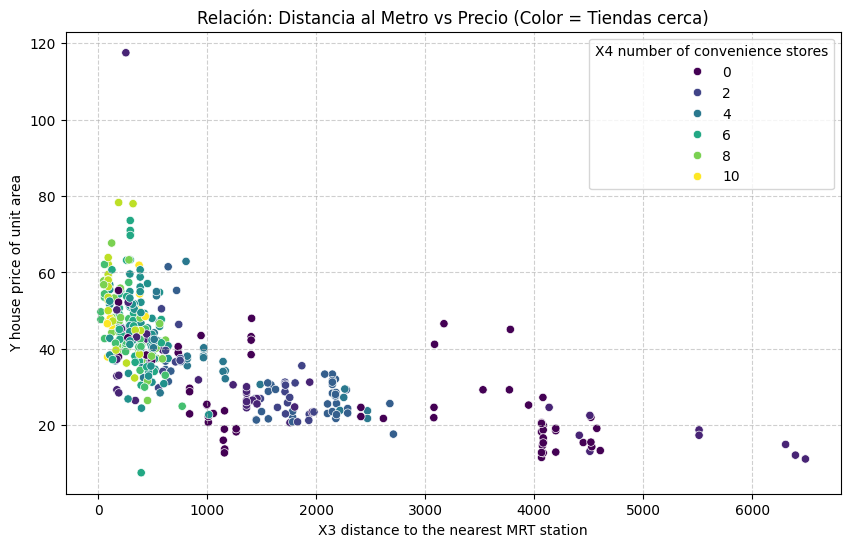

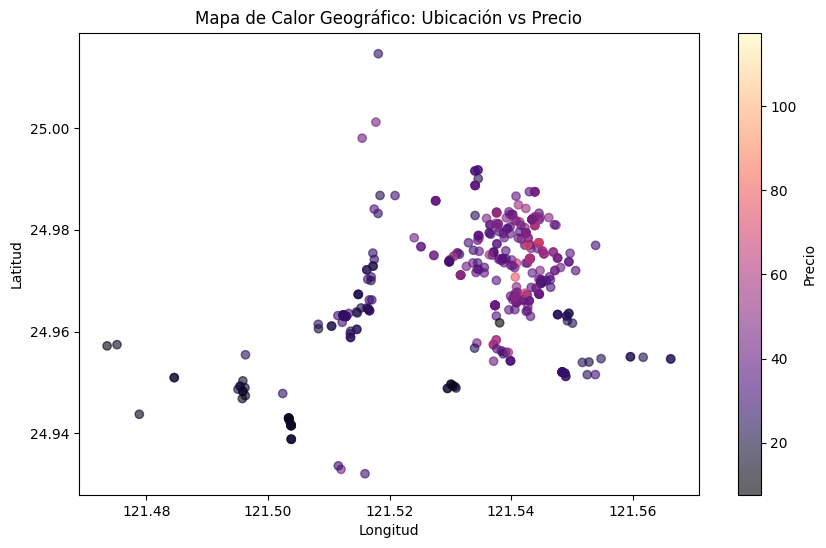

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns
import plotly.graph_objects as go

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)


# 1. CARGA DE DATOS
print("Cargando datos desde UCI Repository...")
real_estate_valuation = fetch_ucirepo(id=477)

# Definimos X (todas las características) - y (el precio)
X = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

# Unimos X e y en un solo DataFrame para el análisis (EDA)
df_eda = pd.concat([X, y], axis=1)

# --- PASO 1: ESTADÍSTICA DESCRIPTIVA ---
# Esto nos da la media, mínimos, máximos y desviación estándar de todas las variables.
print("\n--- Resumen Estadístico ---")
print(df_eda.describe())

# --- PASO 2: MATRIZ DE CORRELACIÓN ---
# Queremos ver qué variables están más unidas al precio (Y).
plt.figure(figsize=(10, 8))
correlation_matrix = df_eda.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación: ¿Qué influye más en el precio?")
plt.show()

# --- PASO 3: DISTRIBUCIÓN DEL PRECIO (Variable Y) ---
# Queremos saber si la mayoría de las casas son baratas, caras o están en el promedio.
plt.figure(figsize=(8, 5))
sns.histplot(df_eda['Y house price of unit area'], kde=True, color='green')
plt.title("Distribución de los Precios de las Casas")
plt.xlabel("Precio por unidad de área")
plt.ylabel("Frecuencia")
plt.show()

# --- PASO 4: RELACIÓN CLAVE (Distancia al Metro vs Precio) ---
# Según la teoría, a menor distancia al MRT, mayor debería ser el precio.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='X3 distance to the nearest MRT station',
                y='Y house price of unit area',
                hue='X4 number of convenience stores',
                data=df_eda,
                palette='viridis')
plt.title("Relación: Distancia al Metro vs Precio (Color = Tiendas cerca)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- PASO 5: ANÁLISIS GEOGRÁFICO ---
# Usamos Latitud y Longitud para ver dónde están las zonas más caras.
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_eda['X6 longitude'], df_eda['X5 latitude'],
            c=df_eda['Y house price of unit area'], cmap='magma', alpha=0.6)
plt.colorbar(scatter, label='Precio')
plt.title("Mapa de Calor Geográfico: Ubicación vs Precio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


1. Perfil General del Inventario (Estadística Descriptiva)
Al analizar nuestras 414 propiedades, detectamos que el mercado es muy diverso:

Precio Promedio: 38 unidades por área. Sin embargo, tenemos una brecha enorme: desde propiedades muy económicas (7.6) hasta propiedades de lujo (117.5).

La Variable Crítica (Transporte): El 50% de nuestras casas están a menos de 500 metros de una estación de metro. Esto nos dice que estamos ante un mercado altamente urbanizado y dependiente de la movilidad.

Antigüedad: Tenemos casas desde recién construidas (0 años) hasta de 43 años, con un promedio de 17 años.

2. ¿Qué "mueve la aguja" del precio? (Matriz de Correlación)
No todos los datos valen lo mismo. Nuestro análisis revela tres reglas de oro en este negocio:

Regla de la Proximidad: La distancia al metro es el factor número uno. A medida que una casa se aleja del transporte, su valor cae drásticamente.

Regla de la Conveniencia: El número de tiendas de conveniencia  alrededor de la casa tiene un impacto positivo directo en el precio. A la gente le importa la facilidad de compra.

Regla Geográfica: Existe unaa zona de alta plusvalía en el mapa (identificado por latitud/longitud) donde los precios son naturalmente superiores, independientemente de la edad de la casa.

3. Hallazgos Visuales Clave (Gráficas y Mapas)
Comportamiento del Precio (Histograma): La mayoría de las casas se venden entre 25 y 45 unidades. Las casas que superan las 60 unidades son "excepciones" de lujo que deben analizarse por separado para no distorsionar el promedio.

El "Efecto Tobogán" (Scatter Plot): Al graficar Distancia vs. Precio, vemos que el valor cae en picada después de los primeros 1,000 metros de distancia al metro. Si una propiedad está a más de 1.5 km, su precio se estanca en el nivel más bajo.

Mapa de Calor Inmobiliario: Visualmente, los precios más altos (colores brillantes) no están dispersos, sino concentrados en un "núcleo" geográfico. Esto nos sugiere que estamos ante un mercado de "centros de ciudad" fuertes.

4. Conclusiones y Próximos Pasos para el Negocio
Para cualquier persona que esté conociendo este negocio, estas son las 3 verdades:

El valor está en el tiempo: El tiempo de traslado (distancia al metro) es lo que el cliente está pagando realmente, no solo los ladrillos.

Micro-entorno: Una casa con 10 tiendas cerca vale significativamente más que una con solo 2, aunque sean iguales por dentro.

Hacia el Modelo Predictivo: Con estos datos, ahora estamos listos para crear una herramienta que, con solo darle la ubicación y las tiendas cercanas, nos diga el precio justo de mercado con un margen de error mínimo.
En resumen: Si vas a comprar o vender en este mercado, mira el mapa y cuenta las tiendas. El resto de los factores (como la edad de la casa o la fecha de venta) influyen, pero no tanto como la ubicación y el servicio.

pero para este caso de estudio vamos a realizar el modelo con todos las caracteristicas del dataset.



In [ ]:
# 1. LIMPIEZA
# Eliminamos la columna 'No' porque es un índice que no tiene relación con el precio.
if 'No' in X.columns:
    X = X.drop(columns=['No'])

# --- PASO 6: SEPARACIÓN Y PARTICIÓN DEL DATASET ---

# Partimos el dataset: 80% para entrenar y 20% para validar
# Importante: random_state asegura que si repites el código, la partición sea la misma.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Partición Completada ---")
print(f"Total de datos: {len(X)}")
print(f"Entrenamiento: {len(X_train)} filas")
print(f"Validación: {len(X_test)} filas")

# --- PASO 7: ESCALADO (StandardScaler) ---
# Ahora que están separados, escalamos para que el Gradiente Descendente funcione bien.
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos los datos de prueba con la misma escala
X_test_scaled = scaler.transform(X_test)

print("\nDatos escalados y listos para el modelo.")


--- Partición Completada ---
Total de datos: 414
Entrenamiento: 331 filas
Validación: 83 filas

Datos escalados y listos para el modelo.


In [ ]:
# MINIMOS CUADRADOS ORDINARIOS OLS

#1. Preparar los datos: Añadir columna de unos para el Bias (Intercepto)
# Usamos los datos de entrenamiento (puedes usar los escalados o los originales,
# OLS funciona con ambos, pero para matrices es común usar los originales o estandarizados)
X_unos = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]

# 2. Aplicar la Ecuación Normal: W = (X.T * X)^-1 * X.T * y
# np.linalg.inv calcula la inversa
# .T calcula la transpuesta
# @ es el operador para multiplicación de matrices en Python
y_train_vec = y_train.values.reshape(-1, 1) # Aseguramos que 'y' sea un vector columna

W_optimal = np.linalg.inv(X_unos.T @ X_unos) @ X_unos.T @ y_train_vec

# 3. Mostrar los resultados
print("--- Parámetros Estimados (OLS Matricial) ---")
print(f"Intercepto: {W_optimal[0][0]:.4f}")
for i, nombre in enumerate(X.columns):
    print(f"Peso para {nombre} ({i+1}): {W_optimal[i+1][0]:.4f}")

--- Parámetros Estimados (OLS Matricial) ---
Intercepto: 38.3915
Peso para X1 transaction date (1): 1.5296
Peso para X2 house age (2): -3.0627
Peso para X3 distance to the nearest MRT station (3): -5.7869
Peso para X4 number of convenience stores (4): 3.2189
Peso para X5 latitude (5): 2.8551
Peso para X6 longitude (6): -0.4410
